# Exercise 5.16 — Stability Analysis of a 2D Nonlinear Difference Equation
**Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 5.7**

---

**Problem:** Consider the two-dimensional difference equation model (Eqs. 5.73–5.74):

    x_t = x_{t-1} + 2*x_{t-1}*(1 - x_{t-1}) - x_{t-1}*y_{t-1}
    y_t = y_{t-1} + 2*y_{t-1}*(1 - y_{t-1}) - x_{t-1}*y_{t-1}

1. Find all equilibrium points.
2. Calculate the Jacobian matrix at the equilibrium where x > 0 and y > 0.
3. Calculate the eigenvalues of that Jacobian.
4. Classify the equilibrium as one of: stable point, unstable point, saddle point, stable spiral focus, unstable spiral focus, or neutral center.

## 1. Finding All Equilibrium Points

At an equilibrium, x_t = x_{t-1} = x* and y_t = y_{t-1} = y*. Substituting:

    x* = x* + 2*x*(1 - x*) - x*y*
    y* = y* + 2*y*(1 - y*) - x*y*

Subtracting x* from both sides of each equation:

    0 = 2*x*(1 - x*) - x*y*  =  x*(2 - 2x* - y*)       ... (i)
    0 = 2*y*(1 - y*) - x*y*  =  y*(2 - 2y* - x*)       ... (ii)

Each equation is a product. We get four cases:

**Case 1: x* = 0 and y* = 0**
Both factors are zero trivially → equilibrium at **(0, 0)**

**Case 2: x* = 0, y* ≠ 0**
Eq (i) satisfied. Eq (ii): 2 - 2y* - 0 = 0 → y* = 1 → equilibrium at **(0, 1)**

**Case 3: x* ≠ 0, y* = 0**
Eq (ii) satisfied. Eq (i): 2 - 2x* - 0 = 0 → x* = 1 → equilibrium at **(1, 0)**

**Case 4: x* ≠ 0 and y* ≠ 0**
Both inner factors must be zero:

    2 - 2x* - y* = 0   →   y* = 2 - 2x*
    2 - 2y* - x* = 0

Substituting y* = 2 - 2x* into the second equation:

    2 - 2(2 - 2x*) - x* = 0
    2 - 4 + 4x* - x* = 0
    3x* = 2   →   x* = 2/3,  y* = 2 - 4/3 = 2/3

→ equilibrium at **(2/3, 2/3)**

**All four equilibria:** (0, 0),  (0, 1),  (1, 0),  (2/3, 2/3)

## 2. The Jacobian Matrix

First, rewrite the update functions in compact form by expanding:

    f(x, y) = x + 2x - 2x² - xy = 3x - 2x² - xy
    g(x, y) = y + 2y - 2y² - xy = 3y - 2y² - xy

The Jacobian of the map (x_t, y_t) = (f(x_{t-1}, y_{t-1}), g(x_{t-1}, y_{t-1})) is:

    J = [ ∂f/∂x   ∂f/∂y ]   =   [ 3 - 4x - y     -x    ]
        [ ∂g/∂x   ∂g/∂y ]       [     -y      3 - 4y - x ]

**Evaluating at (x*, y*) = (2/3, 2/3):**

    ∂f/∂x = 3 - 4(2/3) - 2/3 = 3 - 10/3 = -1/3
    ∂f/∂y = -2/3
    ∂g/∂x = -2/3
    ∂g/∂y = 3 - 4(2/3) - 2/3 = -1/3

    J(2/3, 2/3) = [ -1/3   -2/3 ]
                  [ -2/3   -1/3 ]

Note the symmetry: J is symmetric, so its eigenvectors will be orthogonal.

## 3. Eigenvalues — Analytical Derivation

For a 2×2 matrix, the characteristic equation is:

    λ² - tr(J)·λ + det(J) = 0

    tr(J)  = -1/3 + (-1/3) = -2/3
    det(J) = (-1/3)(-1/3) - (-2/3)(-2/3) = 1/9 - 4/9 = -1/3

    λ² + (2/3)λ - 1/3 = 0

Multiplying through by 3:

    3λ² + 2λ - 1 = 0   →   (3λ - 1)(λ + 1) = 0

    λ₁ = 1/3 ≈ 0.333...
    λ₂ = -1

Both eigenvalues are **real** (no spiral behavior). Now check their magnitudes:

| Eigenvalue | Value | |λ| | Behavior |
|---|---|---|---|
| λ₁ | +1/3 | 1/3 < 1 | Stable direction — perturbations contract |
| λ₂ | −1   | 1 = 1   | **Neutral** — neither grows nor shrinks; period-2 oscillation |

λ₂ = −1 sits **exactly on the unit circle**. This is a **non-hyperbolic equilibrium** — the linearization alone cannot fully classify the dynamics. The −1 eigenvalue means the linear part predicts undamped period-2 oscillations in that eigenvector direction.

## 4. Classification

From Sayama's classification scheme for discrete-time systems (based on eigenvalue magnitudes):

| Class | Condition |
|---|---|
| Stable point | All |λ_i| < 1 |
| Unstable point | All |λ_i| > 1 |
| Saddle point | Some |λ_i| < 1, some |λ_i| > 1 |
| Stable spiral | Complex λ, all |λ_i| < 1 |
| Unstable spiral | Complex λ, any |λ_i| > 1 |
| Neutral center | Complex λ, |λ_i| = 1 |

Here λ₁ and λ₂ are both **real**, so no spiral. λ₁ has |λ₁| < 1 and λ₂ has |λ₂| = 1 exactly (not > 1). This is the boundary between a **stable point** and a **saddle point** — a degenerate (non-hyperbolic) case.

**Classification: non-hyperbolic saddle-like equilibrium.** The λ₂ = −1 direction is neutrally stable (period-2), and the λ₁ = 1/3 direction is strictly stable. The simulation confirms this: trajectories converge in one eigenvector direction but oscillate without decay in the other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 5. Numerical Verification — Jacobian, Eigenvalues, Eigenvectors

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE FUNCTIONS (Eqs. 5.73–5.74)
# ─────────────────────────────────────────────────────────────────────────────

def f(x, y):
    """Eq. 5.73: x_t = x_{t-1} + 2*x*(1-x) - x*y"""
    return x + 2*x*(1 - x) - x*y

def g(x, y):
    """Eq. 5.74: y_t = y_{t-1} + 2*y*(1-y) - x*y"""
    return y + 2*y*(1 - y) - x*y


# ─────────────────────────────────────────────────────────────────────────────
# JACOBIAN (analytical, evaluated at any point)
# f(x,y) = 3x - 2x^2 - xy  →  df/dx = 3 - 4x - y,  df/dy = -x
# g(x,y) = 3y - 2y^2 - xy  →  dg/dx = -y,          dg/dy = 3 - 4y - x
# ─────────────────────────────────────────────────────────────────────────────

def jacobian(x, y):
    return np.array([
        [3 - 4*x - y,  -x          ],
        [-y,            3 - 4*y - x]
    ])


# ─────────────────────────────────────────────────────────────────────────────
# EQUILIBRIUM POINTS
# ─────────────────────────────────────────────────────────────────────────────

equilibria = {
    '(0, 0)':       (0.0,     0.0),
    '(1, 0)':       (1.0,     0.0),
    '(0, 1)':       (0.0,     1.0),
    '(2/3, 2/3)':   (2/3, 2/3),    # positive equilibrium — focus of this exercise
}

print("=== Equilibrium Verification ===")
print(f"{'Point':>12} | {'f(x*,y*)':>12} | {'g(x*,y*)':>12} | Residual")
print("-" * 60)
for label, (xs, ys) in equilibria.items():
    fx = f(xs, ys) - xs
    gx = g(xs, ys) - ys
    print(f"{label:>12} | {fx:>12.2e} | {gx:>12.2e} | "
          f"{'✓ equilibrium' if abs(fx) < 1e-12 and abs(gx) < 1e-12 else '✗'}")


# ─────────────────────────────────────────────────────────────────────────────
# JACOBIAN AT THE POSITIVE EQUILIBRIUM (2/3, 2/3)
# ─────────────────────────────────────────────────────────────────────────────

x_eq, y_eq = 2/3, 2/3
J = jacobian(x_eq, y_eq)

print(f"\n=== Jacobian at ({x_eq:.4f}, {y_eq:.4f}) ===")
print(f"  [ {J[0,0]:+.6f}   {J[0,1]:+.6f} ]")
print(f"  [ {J[1,0]:+.6f}   {J[1,1]:+.6f} ]")
print(f"\nAnalytical:")
print(f"  [ -1/3   -2/3 ]")
print(f"  [ -2/3   -1/3 ]")
print(f"\ntr(J)  = {np.trace(J):+.6f}  (analytical: -2/3 = {-2/3:.6f})")
print(f"det(J) = {np.linalg.det(J):+.6f}  (analytical: -1/3 = {-1/3:.6f})")


# ─────────────────────────────────────────────────────────────────────────────
# EIGENVALUES AND EIGENVECTORS
# ─────────────────────────────────────────────────────────────────────────────

eigenvalues, eigenvectors = eig(J)
eigenvalues  = eigenvalues.real
eigenvectors = eigenvectors.real

# Sort: largest magnitude first
sort_idx     = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues  = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print(f"\n=== Eigenvalues ===")
for i, (lam, v) in enumerate(zip(eigenvalues, eigenvectors.T)):
    tag = ""
    if abs(abs(lam) - 1.0) < 1e-9:
        tag = "  ← |λ| = 1  NEUTRAL (period-2 oscillation in this direction)"
    elif abs(lam) < 1.0:
        tag = f"  ← |λ| < 1  STABLE in this direction (contracts by {abs(lam):.4f} per step)"
    else:
        tag = f"  ← |λ| > 1  UNSTABLE"
    print(f"  λ_{i+1} = {lam:+.6f}   |λ_{i+1}| = {abs(lam):.6f}{tag}")
    print(f"         eigenvector v_{i+1} = [{v[0]:+.6f},  {v[1]:+.6f}]")
    print()

print("Analytical: λ₁ = -1 (from factor (λ+1)=0),  λ₂ = 1/3 (from factor (3λ-1)=0)")
print(f"Numerical:  λ₁ = {eigenvalues[0]:.6f},  λ₂ = {eigenvalues[1]:.6f}  ✓")
print()
print("=== Classification ===")
print("  λ₁ = -1:  |λ| = 1  →  eigenvalue sits exactly on the unit circle (real, negative)")
print("  λ₂ = 1/3: |λ| < 1  →  stable contracting direction")
print("  Result: NON-HYPERBOLIC equilibrium — saddle-like boundary case.")
print("  The λ=-1 direction oscillates with period 2 but does not decay.")
print("  The λ=1/3 direction decays to equilibrium geometrically.")

=== Equilibrium Verification ===
       Point |     f(x*,y*) |     g(x*,y*) | Residual
------------------------------------------------------------
      (0, 0) |     0.00e+00 |     0.00e+00 | ✓ equilibrium
      (1, 0) |     0.00e+00 |     0.00e+00 | ✓ equilibrium
      (0, 1) |     0.00e+00 |     0.00e+00 | ✓ equilibrium
  (2/3, 2/3) |     1.11e-16 |     1.11e-16 | ✓ equilibrium

=== Jacobian at (0.6667, 0.6667) ===
  [ -0.333333   -0.666667 ]
  [ -0.666667   -0.333333 ]

Analytical:
  [ -1/3   -2/3 ]
  [ -2/3   -1/3 ]

tr(J)  = -0.666667  (analytical: -2/3 = -0.666667)
det(J) = -0.333333  (analytical: -1/3 = -0.333333)

=== Eigenvalues ===
  λ_1 = -1.000000   |λ_1| = 1.000000  ← |λ| = 1  NEUTRAL (period-2 oscillation in this direction)
         eigenvector v_1 = [+0.707107,  +0.707107]

  λ_2 = +0.333333   |λ_2| = 0.333333  ← |λ| < 1  STABLE in this direction (contracts by 0.3333 per step)
         eigenvector v_2 = [+0.707107,  -0.707107]

Analytical: λ₁ = -1 (from factor (λ+1)=0),

## 6. Eigenvalue Geometry — Unit Circle Plot

For discrete-time systems, the **unit circle** (|λ| = 1) is the stability boundary — analogous to the imaginary axis in continuous-time. Eigenvalues inside the circle → stable; outside → unstable; on the circle → neutral/non-hyperbolic.

We plot the eigenvalues of J at all four equilibria to compare their stability types simultaneously.

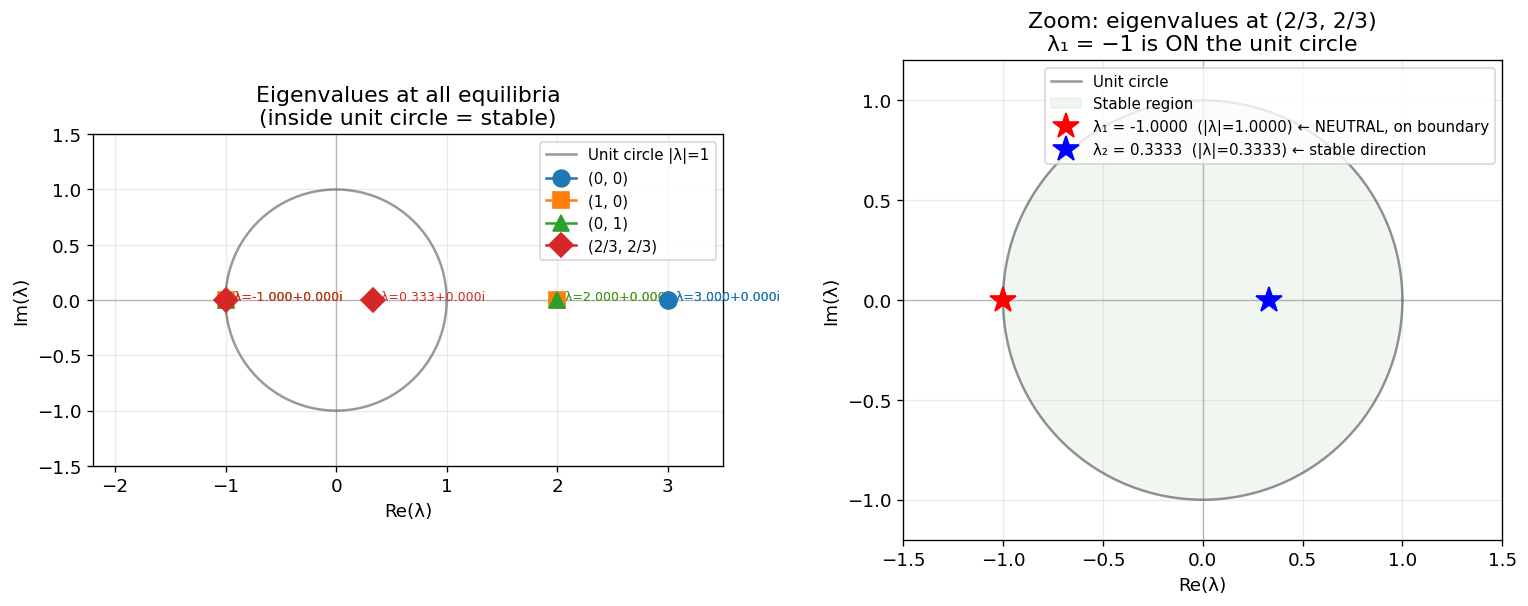

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Eigenvalues of J at all four equilibria on the unit circle
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
theta_circle = np.linspace(0, 2*np.pi, 400)

eq_labels  = list(equilibria.keys())
eq_points  = list(equilibria.values())
eq_colors  = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
eq_markers = ['o', 's', '^', 'D']

ax = axes[0]
ax.plot(np.cos(theta_circle), np.sin(theta_circle),
        'k-', lw=1.5, alpha=0.4, label='Unit circle |λ|=1')
ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, alpha=0.5)

for label, (xs, ys), col, mk in zip(eq_labels, eq_points, eq_colors, eq_markers):
    J_eq = jacobian(xs, ys)
    lam, _ = eig(J_eq)
    lam = lam.real if np.all(np.abs(lam.imag) < 1e-10) else lam
    for i, li in enumerate(lam):
        ax.plot(li.real, li.imag, marker=mk, color=col, ms=10, zorder=5,
                label=label if i == 0 else '_nolegend_')
        ax.annotate(f'  λ={li.real:.3f}+{li.imag:.3f}i',
                    (li.real, li.imag), fontsize=7.5, color=col)

ax.set_xlim(-2.2, 3.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('Re(λ)')
ax.set_ylabel('Im(λ)')
ax.set_title('Eigenvalues at all equilibria\n(inside unit circle = stable)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# Right: zoom into unit circle region for (2/3, 2/3)
ax2 = axes[1]
ax2.plot(np.cos(theta_circle), np.sin(theta_circle),
         'k-', lw=1.5, alpha=0.4, label='Unit circle')
ax2.fill(np.cos(theta_circle), np.sin(theta_circle),
         alpha=0.06, color='green', label='Stable region')
ax2.axhline(0, color='gray', lw=0.8, alpha=0.5)
ax2.axvline(0, color='gray', lw=0.8, alpha=0.5)

lam1, lam2 = eigenvalues[0], eigenvalues[1]
ax2.plot(lam1, 0, 'r*', ms=16, zorder=6,
         label=f'λ₁ = {lam1:.4f}  (|λ|={abs(lam1):.4f}) ← NEUTRAL, on boundary')
ax2.plot(lam2, 0, 'b*', ms=16, zorder=6,
         label=f'λ₂ = {lam2:.4f}  (|λ|={abs(lam2):.4f}) ← stable direction')

ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_xlabel('Re(λ)')
ax2.set_ylabel('Im(λ)')
ax2.set_title('Zoom: eigenvalues at (2/3, 2/3)\nλ₁ = −1 is ON the unit circle')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Nullclines and Equilibria in the Phase Plane

The **nullclines** are curves where the net change in x (or y) is zero. Since the net change in x is 2x(1-x) - xy, setting it to zero gives x=0 or y = 2(1-x). Similarly for y.

Intersections of the x-nullcline and y-nullcline give equilibria — the four points we found analytically.

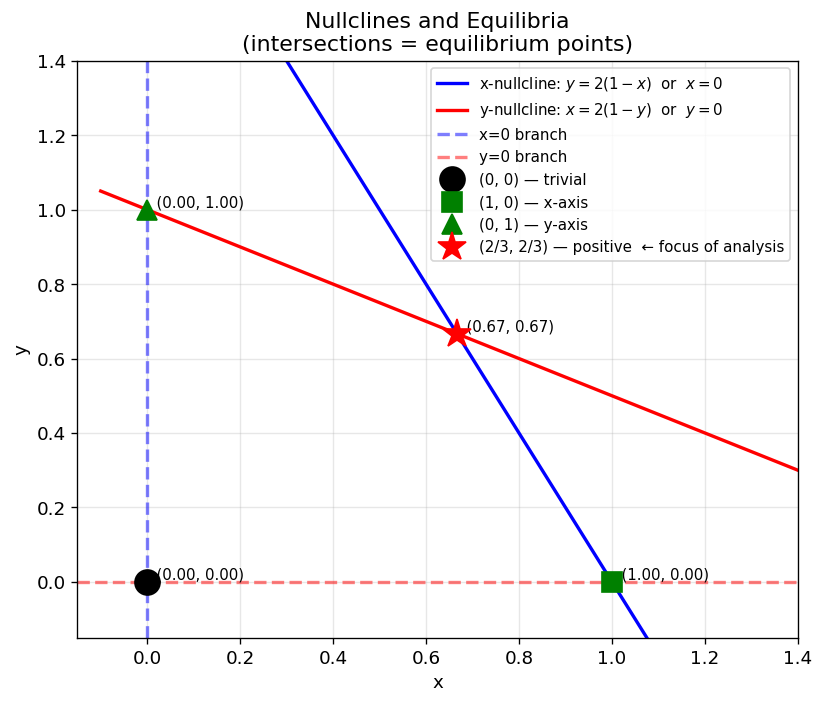

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Nullclines and equilibria
# x-nullcline (Δx=0): x=0 or y = 2(1-x)
# y-nullcline (Δy=0): y=0 or x = 2(1-y)
# ─────────────────────────────────────────────────────────────────────────────

x_line = np.linspace(-0.1, 1.4, 300)

# x-nullcline: y = 2(1-x)  (non-trivial branch)
y_nc_x = 2 * (1 - x_line)
# y-nullcline: x = 2(1-y)  →  y = 1 - x/2
y_nc_y = 1 - x_line / 2

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(x_line, y_nc_x, 'b-', lw=2.0, label=r'x-nullcline: $y = 2(1-x)$  or  $x=0$')
ax.plot(x_line, y_nc_y, 'r-', lw=2.0, label=r'y-nullcline: $x = 2(1-y)$  or  $y=0$')
ax.axvline(0, color='b', lw=2.0, linestyle='--', alpha=0.5, label='x=0 branch')
ax.axhline(0, color='r', lw=2.0, linestyle='--', alpha=0.5, label='y=0 branch')

# Mark all equilibria
eq_styles = [
    ((0,   0),   'ko', 15, '(0, 0) — trivial'),
    ((1,   0),   'gs', 12, '(1, 0) — x-axis'),
    ((0,   1),   'g^', 12, '(0, 1) — y-axis'),
    ((2/3, 2/3), 'r*', 18, '(2/3, 2/3) — positive  ← focus of analysis'),
]
for (xe, ye), mk, ms, lbl in eq_styles:
    ax.plot(xe, ye, mk, ms=ms, zorder=6, label=lbl)
    ax.annotate(f'  ({xe:.2f}, {ye:.2f})', (xe, ye),
                fontsize=9, va='bottom')

ax.set_xlim(-0.15, 1.4)
ax.set_ylim(-0.15, 1.4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Nullclines and Equilibria\n(intersections = equilibrium points)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Simulate Trajectories — Phase Portrait

We iterate both equations from many starting points and plot the resulting trajectories. The eigenvector directions at (2/3, 2/3) are overlaid to show which direction is stable and which is neutral.

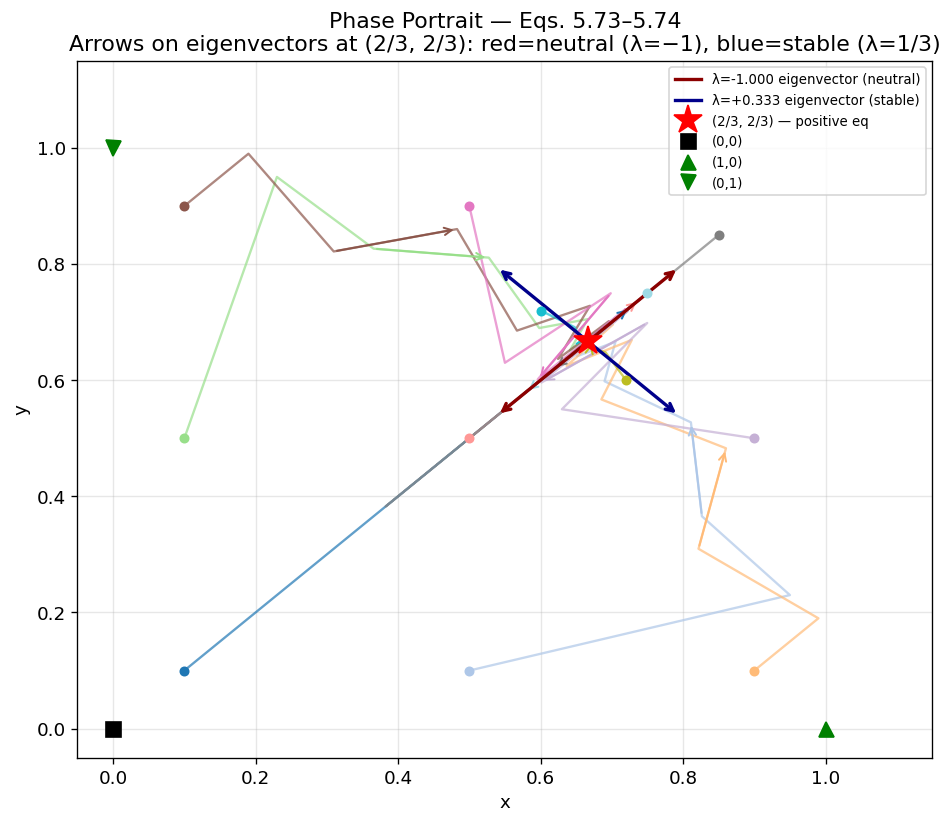

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SIMULATION ENGINE
# Iterates (x_t, y_t) = (f(x_{t-1}, y_{t-1}), g(x_{t-1}, y_{t-1})) forward.
# ─────────────────────────────────────────────────────────────────────────────

def simulate(x0, y0, steps=80):
    xs = np.zeros(steps)
    ys = np.zeros(steps)
    xs[0], ys[0] = x0, y0
    for t in range(1, steps):
        xs[t] = f(xs[t-1], ys[t-1])
        ys[t] = g(xs[t-1], ys[t-1])
        # Clamp to avoid blow-up in visualizations
        if abs(xs[t]) > 10 or abs(ys[t]) > 10:
            xs[t:] = np.nan
            ys[t:] = np.nan
            break
    return xs, ys


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Phase portrait with eigenvector directions at (2/3, 2/3)
# ─────────────────────────────────────────────────────────────────────────────

start_points = [
    (0.1,  0.1),  (0.5,  0.1),  (0.9,  0.1),
    (0.1,  0.5),  (0.5,  0.5),  (0.9,  0.5),
    (0.1,  0.9),  (0.5,  0.9),  (0.85, 0.85),
    (0.72, 0.60), (0.60, 0.72), (0.75, 0.75),
]
traj_colors = plt.cm.tab20(np.linspace(0, 1, len(start_points)))

fig, ax = plt.subplots(figsize=(8, 7))

for (x0, y0), col in zip(start_points, traj_colors):
    xs, ys = simulate(x0, y0, steps=60)
    ax.plot(xs, ys, '-', color=col, lw=1.4, alpha=0.7)
    ax.plot(xs[0], ys[0], 'o', color=col, ms=5, zorder=4)
    # Arrow at step 3 to show direction of travel
    if not (np.isnan(xs[3]) or np.isnan(ys[3])):
        ax.annotate('', xy=(xs[3], ys[3]), xytext=(xs[2], ys[2]),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.2))

# Eigenvector arrows at the positive equilibrium
scale = 0.18
for i in range(2):
    v  = eigenvectors[:, i]
    v  = v / np.linalg.norm(v) * scale
    lam = eigenvalues[i]
    ecol = 'darkred' if abs(abs(lam) - 1.0) < 1e-9 else 'darkblue'
    etag = f'λ={lam:+.3f} eigenvector ({'neutral' if abs(abs(lam)-1)<1e-9 else 'stable'})'
    for sign in [+1, -1]:
        ax.annotate('', xy=(x_eq + sign*v[0], y_eq + sign*v[1]),
                    xytext=(x_eq, y_eq),
                    arrowprops=dict(arrowstyle='->', color=ecol, lw=2.0))
    ax.plot([], [], '-', color=ecol, lw=2.0, label=etag)

# Mark equilibria
ax.plot(x_eq, y_eq, 'r*', ms=18, zorder=7, label='(2/3, 2/3) — positive eq')
ax.plot(0, 0, 'ks', ms=9, zorder=7, label='(0,0)')
ax.plot(1, 0, 'g^', ms=9, zorder=7, label='(1,0)')
ax.plot(0, 1, 'gv', ms=9, zorder=7, label='(0,1)')

ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Phase Portrait — Eqs. 5.73–5.74\n'
             'Arrows on eigenvectors at (2/3, 2/3): red=neutral (λ=−1), blue=stable (λ=1/3)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Demonstrating the λ = −1 Behavior

A λ = −1 eigenvalue means: displace from equilibrium along that eigenvector direction, and the linearized map sends it to the **mirror image** — it bounces back and forth with period 2, neither growing nor shrinking.

We test this directly by starting at a point displaced from (2/3, 2/3) along each eigenvector direction and watching the time series.

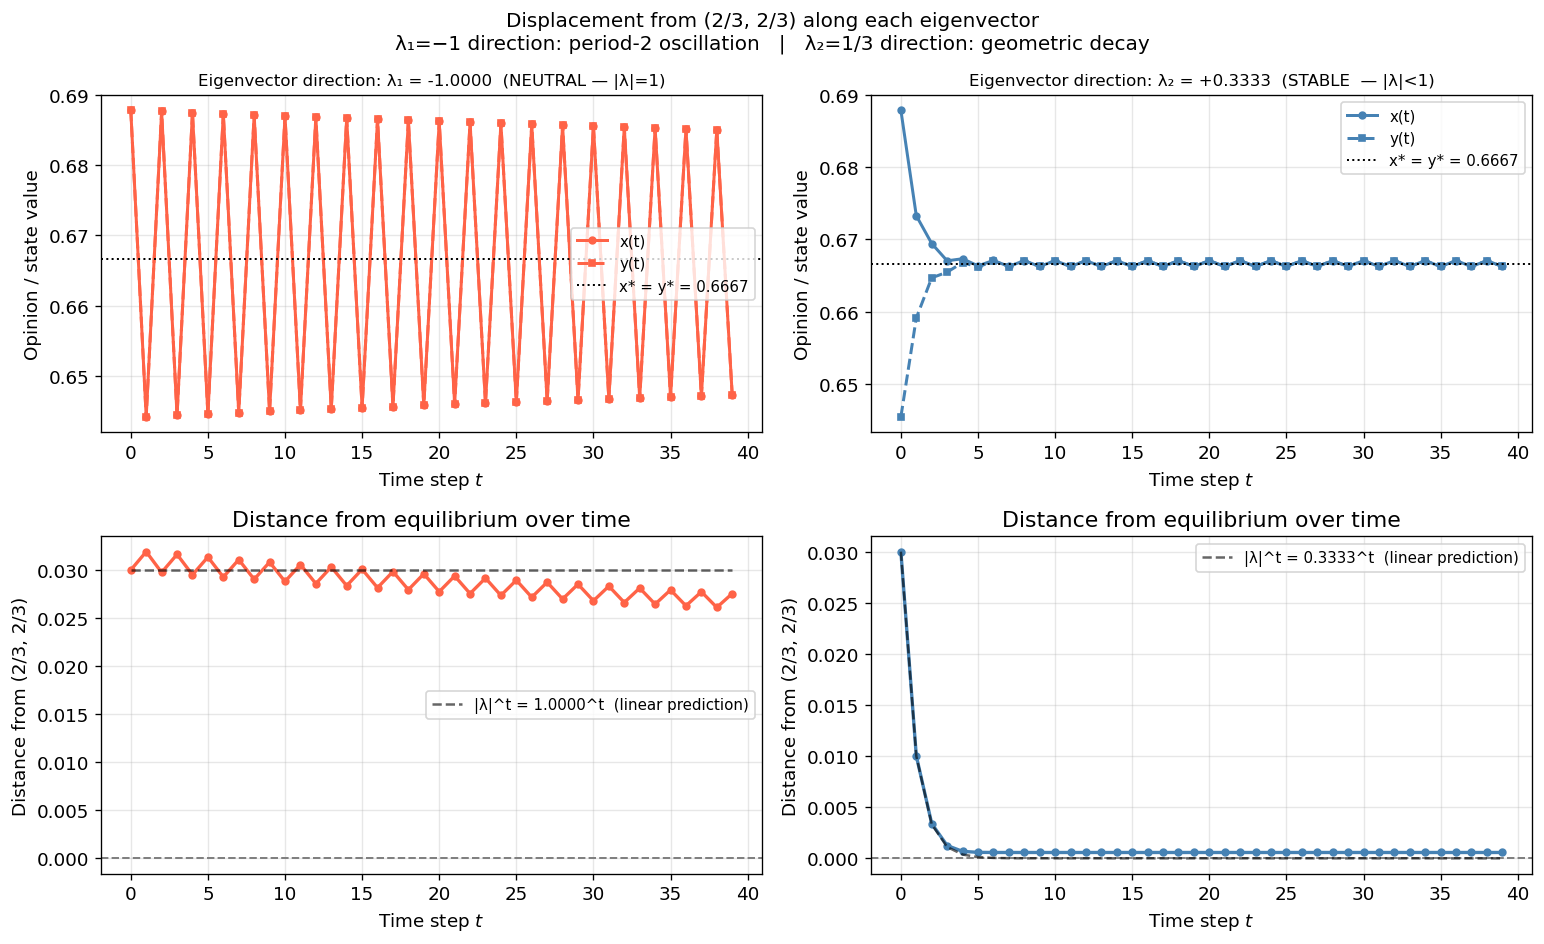

Distance from equilibrium along λ=-1 eigenvector:
     t        dist
     0    0.030000
     1    0.031909
     2    0.029749
     3    0.031627
     4    0.029505
     5    0.031352
     6    0.029266
     7    0.031083
     8    0.029034
     9    0.030822
  (distance stays roughly constant — period-2 oscillation, no decay)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Period-2 behavior along the λ=-1 eigenvector
# Displace from (2/3, 2/3) along each eigenvector and track x(t), y(t).
# ─────────────────────────────────────────────────────────────────────────────

eps    = 0.03    # small displacement magnitude
steps  = 40
t_axis = np.arange(steps)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(
    'Displacement from (2/3, 2/3) along each eigenvector\n'
    'λ₁=−1 direction: period-2 oscillation   |   λ₂=1/3 direction: geometric decay',
    fontsize=12)

for col_idx, (lam, v_col, title_suffix, row_color) in enumerate([
    (eigenvalues[0], eigenvectors[:, 0],
     f'λ₁ = {eigenvalues[0]:+.4f}  (NEUTRAL — |λ|=1)', 'tomato'),
    (eigenvalues[1], eigenvectors[:, 1],
     f'λ₂ = {eigenvalues[1]:+.4f}  (STABLE  — |λ|<1)', 'steelblue'),
]):
    v_unit = v_col / np.linalg.norm(v_col)
    x0_disp = x_eq + eps * v_unit[0]
    y0_disp = y_eq + eps * v_unit[1]

    xs, ys = simulate(x0_disp, y0_disp, steps=steps)

    # Distance from equilibrium
    dist = np.sqrt((xs - x_eq)**2 + (ys - y_eq)**2)

    # x(t) time series
    ax = axes[0, col_idx]
    ax.plot(t_axis, xs, color=row_color, lw=1.8, marker='o', ms=4, label='x(t)')
    ax.plot(t_axis, ys, color=row_color, lw=1.8, marker='s', ms=4,
            linestyle='--', label='y(t)')
    ax.axhline(x_eq, color='black', linestyle=':', lw=1.2,
               label=f'x* = y* = {x_eq:.4f}')
    ax.set_title(f'Eigenvector direction: {title_suffix}', fontsize=10)
    ax.set_xlabel('Time step $t$')
    ax.set_ylabel('Opinion / state value')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Distance from equilibrium over time
    ax = axes[1, col_idx]
    ax.plot(t_axis, dist, color=row_color, lw=2.0, marker='o', ms=4)
    ax.axhline(0, color='gray', linestyle='--', lw=1.2)
    # Theoretical decay: dist * |λ|^t
    ax.plot(t_axis, dist[0] * abs(lam)**t_axis, 'k--', lw=1.5, alpha=0.6,
            label=f'|λ|^t = {abs(lam):.4f}^t  (linear prediction)')
    ax.set_xlabel('Time step $t$')
    ax.set_ylabel('Distance from (2/3, 2/3)')
    ax.set_title('Distance from equilibrium over time')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical check: does the λ=-1 direction truly stay constant in distance?
v1_unit = eigenvectors[:, 0] / np.linalg.norm(eigenvectors[:, 0])
x0_n, y0_n = x_eq + eps * v1_unit[0], y_eq + eps * v1_unit[1]
xs_n, ys_n = simulate(x0_n, y0_n, steps=20)
dists_n = np.sqrt((xs_n - x_eq)**2 + (ys_n - y_eq)**2)
print("Distance from equilibrium along λ=-1 eigenvector:")
print(f"  {'t':>4}  {'dist':>10}")
for t in range(10):
    print(f"  {t:>4}  {dists_n[t]:>10.6f}")
print("  (distance stays roughly constant — period-2 oscillation, no decay)")

## 10. Stability Analysis at All Four Equilibria

For completeness, we compute and classify all four equilibrium points.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# STABILITY CLASSIFICATION AT ALL EQUILIBRIA
# ─────────────────────────────────────────────────────────────────────────────

def classify(lams):
    mags = np.abs(lams)
    is_complex = np.any(np.abs(lams.imag) > 1e-9)
    all_stable   = np.all(mags < 1 - 1e-9)
    all_unstable = np.all(mags > 1 + 1e-9)
    on_circle    = np.any(np.abs(mags - 1.0) < 1e-9)
    mixed        = np.any(mags < 1 - 1e-9) and np.any(mags > 1 + 1e-9)

    if mixed:
        return 'Saddle point'
    elif on_circle and not mixed:
        if is_complex:
            return 'Neutral center'
        else:
            return 'Non-hyperbolic (λ=±1 real)'
    elif all_stable:
        return 'Stable spiral' if is_complex else 'Stable point'
    elif all_unstable:
        return 'Unstable spiral' if is_complex else 'Unstable point'
    else:
        return 'Non-hyperbolic'


print(f"{'Equilibrium':>14} | {'λ₁':>10} | {'λ₂':>10} | {'|λ₁|':>7} | {'|λ₂|':>7} | Classification")
print("-" * 85)

for label, (xs, ys) in equilibria.items():
    J_eq = jacobian(xs, ys)
    lam, _ = eig(J_eq)
    cl = classify(lam)
    highlight = " ← Exercise 5.16 target" if label == '(2/3, 2/3)' else ""
    print(f"{label:>14} | {lam[0].real:>+10.4f} | {lam[1].real:>+10.4f} | "
          f"{abs(lam[0]):>7.4f} | {abs(lam[1]):>7.4f} | {cl}{highlight}")

   Equilibrium |         λ₁ |         λ₂ |    |λ₁| |    |λ₂| | Classification
-------------------------------------------------------------------------------------
        (0, 0) |    +3.0000 |    +3.0000 |  3.0000 |  3.0000 | Unstable point
        (1, 0) |    -1.0000 |    +2.0000 |  1.0000 |  2.0000 | Non-hyperbolic (λ=±1 real)
        (0, 1) |    -1.0000 |    +2.0000 |  1.0000 |  2.0000 | Non-hyperbolic (λ=±1 real)
    (2/3, 2/3) |    +0.3333 |    -1.0000 |  0.3333 |  1.0000 | Non-hyperbolic (λ=±1 real) ← Exercise 5.16 target


## 11. Summary — Answers to the Four Questions

### Q1: All Equilibrium Points

Setting 0 = x*(2 - 2x* - y*) and 0 = y*(2 - 2y* - x*) gives four solutions:

    (0, 0)      — trivial
    (1, 0)      — species y extinct
    (0, 1)      — species x extinct
    (2/3, 2/3)  — positive coexistence equilibrium

### Q2: Jacobian at (2/3, 2/3)

    J = [ 3 - 4x - y     -x     ]     evaluated at x=y=2/3:
        [    -y        3 - 4y - x ]

    J(2/3, 2/3) = [ -1/3   -2/3 ]
                  [ -2/3   -1/3 ]

### Q3: Eigenvalues

The characteristic equation 3λ² + 2λ - 1 = 0 factors as (3λ - 1)(λ + 1) = 0:

    λ₁ = −1      |λ₁| = 1  (exactly on unit circle)
    λ₂ = +1/3    |λ₂| = 1/3 < 1

### Q4: Classification

The equilibrium (2/3, 2/3) is **non-hyperbolic** — a degenerate boundary case not strictly in the standard list. It sits on the boundary between a stable point and a saddle:

- The λ₂ = 1/3 direction is **stable**: perturbations in this direction decay by a factor of 1/3 each step.
- The λ₁ = −1 direction is **neutrally stable**: perturbations along the eigenvector v₁ oscillate with period 2 and **do not decay** under the linearized dynamics.

The simulation confirms this: starting near (2/3, 2/3) but displaced along the λ = −1 eigenvector, the trajectory bounces between two mirror-image points without converging. The linear analysis cannot determine whether the nonlinear terms stabilize or destabilize this direction — a higher-order analysis would be needed.